In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 6

# XGBoost Regression

---

### Objectives

- Load Dataset
- Train XGBoost Regressor
- Evaluate Performance
- Feature Importance
- Save Model

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment if required

# %pip install xgboost
# %pip install joblib

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [4]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print(df.shape)

(8601, 33)


In [5]:
# ==============================================================================
# DEFINE TARGET
# ==============================================================================

TARGET = "Sales"

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [6]:
# ==============================================================================
# REMOVE UNUSED COLUMNS
# ==============================================================================

if "Date" in X.columns:
    X.drop(columns=["Date"], inplace=True)

# Remove target leakage feature
if "Sales_Per_Customer" in X.columns:
    X.drop(columns=["Sales_Per_Customer"], inplace=True)

In [7]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:

    X[col] = encoder.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [8]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(6880, 30)
(1721, 30)


In [9]:
# ==============================================================================
# CREATE XGBOOST MODEL
# ==============================================================================

xgb_model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    objective="reg:squarederror"

)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [10]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [11]:
# ==============================================================================
# TRAIN PREDICTIONS
# ==============================================================================

y_train_pred = xgb_model.predict(X_train)

In [12]:
# ==============================================================================
# TEST PREDICTIONS
# ==============================================================================

y_test_pred = xgb_model.predict(X_test)

In [13]:
# ==============================================================================
# MODEL EVALUATION
# ==============================================================================

mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R² :", round(r2,4))

MAE : 8.56
MSE : 116.03
RMSE : 10.77
R² : 0.9592


In [14]:
# ==============================================================================
# PERFORMANCE TABLE
# ==============================================================================

performance = pd.DataFrame({

    "Metric":["MAE","MSE","RMSE","R²"],

    "Value":[mae,mse,rmse,r2]

})

performance

,Metric,Value
0,MAE,8.562489
1,MSE,116.026202
2,RMSE,10.771546
3,R²,0.959234


In [15]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

prediction_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_test_pred,

    "Error": y_test - y_test_pred

})

prediction_df.head(20)

,Actual,Predicted,Error
5839,6,8.631979,-2.631979
4275,91,95.179192,-4.179192
6086,49,43.965412,5.034588
8265,90,88.554626,1.445374
5493,15,24.847519,-9.847519
1688,127,112.863419,14.136581
5241,59,47.554508,11.445492
221,53,63.208019,-10.208019
239,63,60.645050,2.354950
2208,53,57.341614,-4.341614


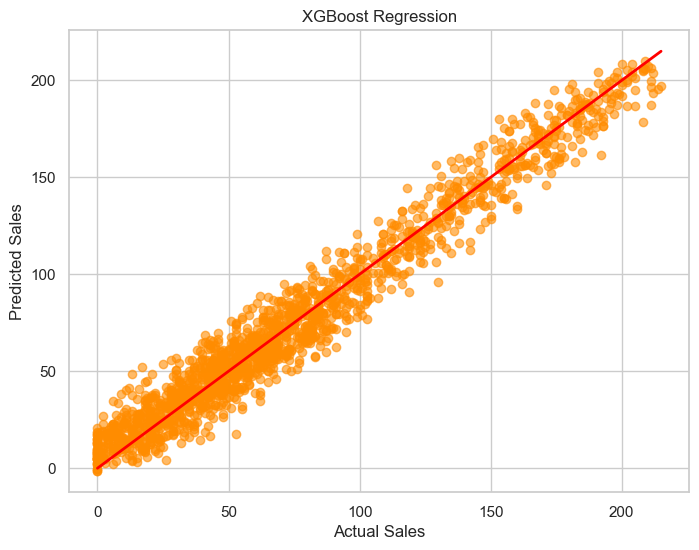

In [17]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    color="darkorange"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("XGBoost Regression")

plt.show()

In [18]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
5,Promotion,0.725057
15,Customers,0.133220
29,Promotion_Impact,0.085774
4,Holiday,0.020535
25,Inventory_Per_Customer,0.008885
11,Inventory,0.004263
14,Discount,0.003139
27,Discount_Amount,0.001573
28,Final_Price,0.001367
18,Day,0.001037


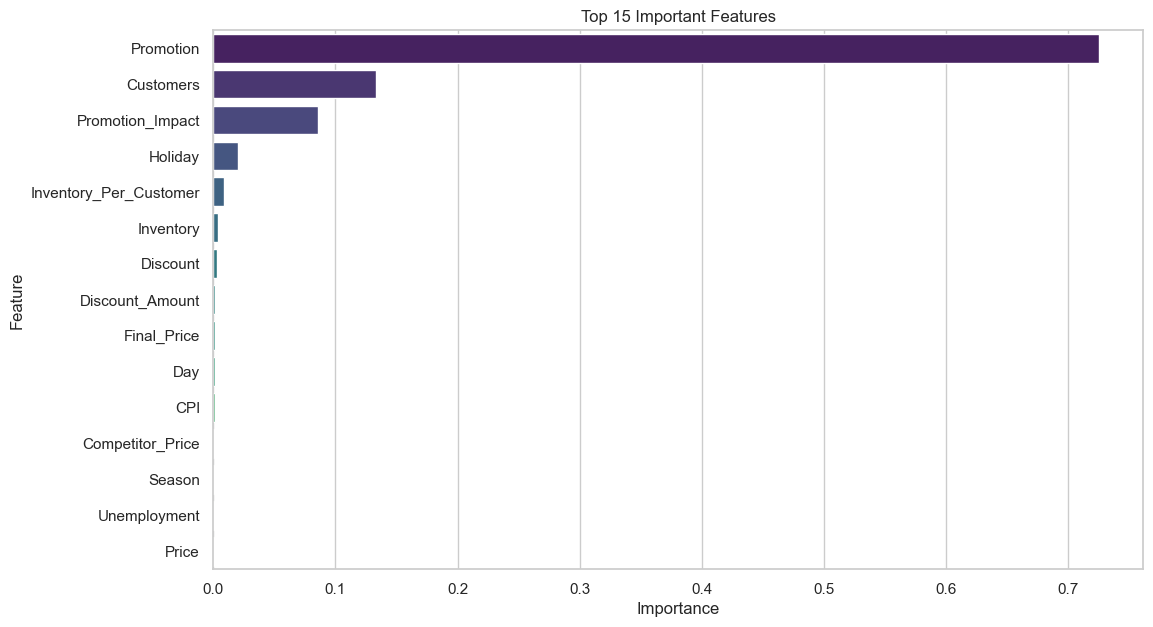

In [19]:
# ==============================================================================
# FEATURE IMPORTANCE PLOT
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.show()

In [21]:
# ==============================================================================
# TRAINING R² SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score :", round(train_r2,4))

Training R² Score : 0.9996


In [22]:
# ==============================================================================
# TESTING R² SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² Score :", round(test_r2,4))

Testing R² Score : 0.9592


In [23]:
# ==============================================================================
# ADJUSTED R² SCORE
# ==============================================================================

n = X_test.shape[0]

p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Adjusted R² :", round(adjusted_r2,4))

Adjusted R² : 0.9585


In [24]:
# ==============================================================================
# MAPE
# ==============================================================================

mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("MAPE :", round(mape,2),"%")

MAPE : inf %


In [25]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

residuals = y_test - y_test_pred

prediction_df["Residual"] = residuals

prediction_df.head()

,Actual,Predicted,Error,Residual
5839,6,8.631979,-2.631979,-2.631979
4275,91,95.179192,-4.179192,-4.179192
6086,49,43.965412,5.034588,5.034588
8265,90,88.554626,1.445374,1.445374
5493,15,24.847519,-9.847519,-9.847519


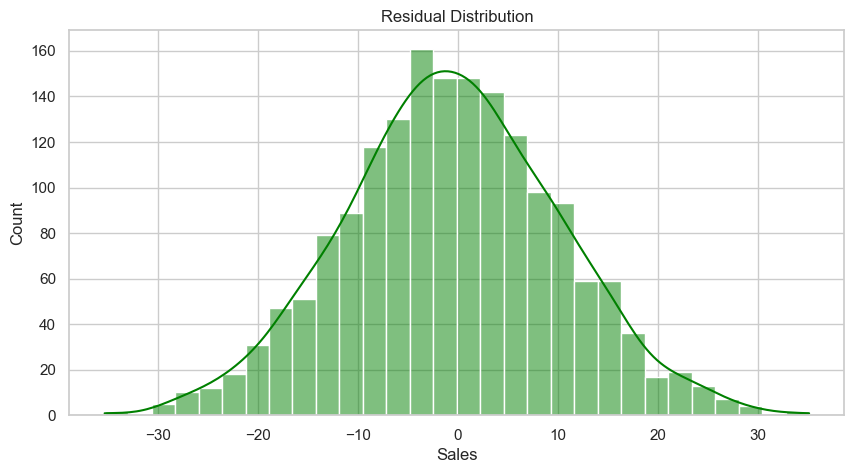

In [26]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="green"
)

plt.title("Residual Distribution")

plt.show()

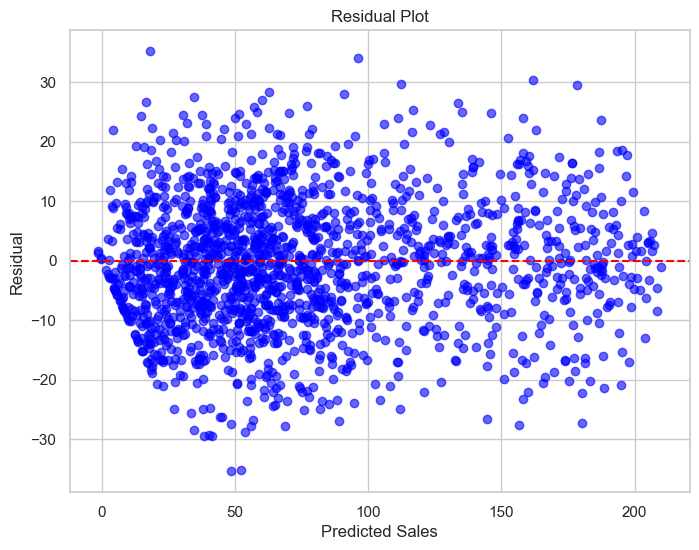

In [27]:
# ==============================================================================
# RESIDUAL SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6,
    color="blue"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [28]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    xgb_model,

    X,

    y,

    cv=5,

    scoring="r2"

)

print(cv_scores)

[0.9626489  0.96123008 0.96118166 0.96075517 0.96221744]


In [29]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", round(cv_scores.mean(),4))

Average CV Score : 0.9616


In [30]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adjusted R²",
        "MAPE",
        "Cross Validation"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        test_r2,
        adjusted_r2,
        mape,
        cv_scores.mean()
    ]

})

summary

,Metric,Value
0,MAE,8.562489
1,MSE,116.026202
2,RMSE,10.771546
3,R²,0.959234
4,Adjusted R²,0.958511
5,MAPE,inf
6,Cross Validation,0.961607


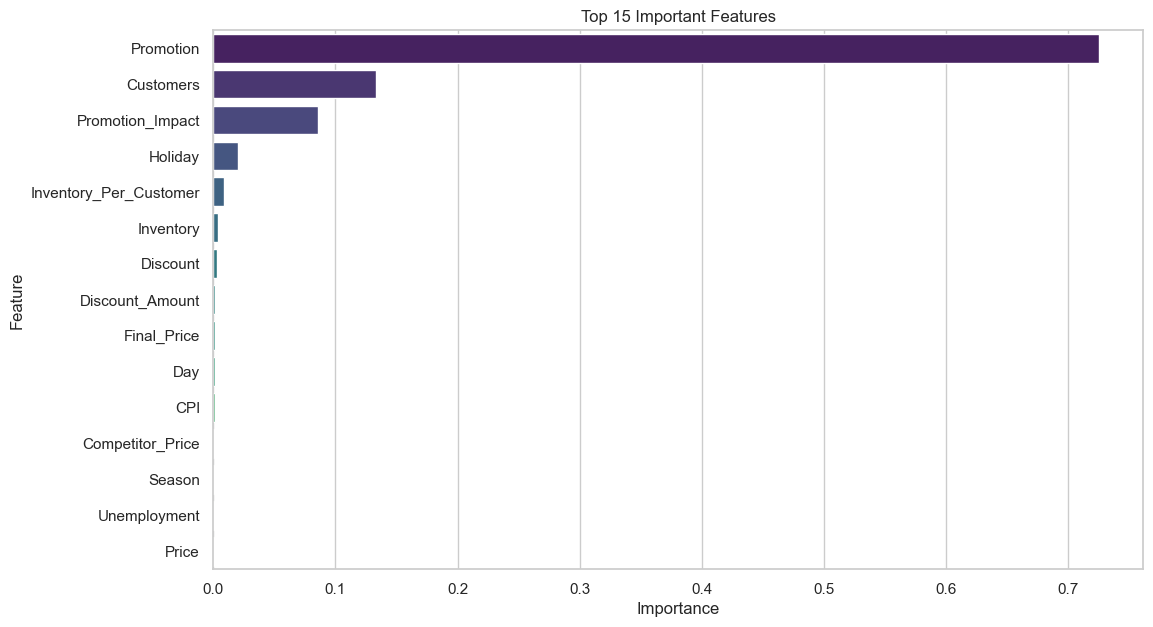

In [31]:
# ==============================================================================
# TOP 15 IMPORTANT FEATURES
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.show()

In [32]:
# ==============================================================================
# FEATURE IMPORTANCE TABLE
# ==============================================================================

importance.head(20)

,Feature,Importance
5,Promotion,0.725057
15,Customers,0.133220
29,Promotion_Impact,0.085774
4,Holiday,0.020535
25,Inventory_Per_Customer,0.008885
11,Inventory,0.004263
14,Discount,0.003139
27,Discount_Amount,0.001573
28,Final_Price,0.001367
18,Day,0.001037


In [33]:
# ==============================================================================
# SAVE MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    xgb_model,
    "model/xgboost_model.pkl"
)

print("XGBoost Model Saved Successfully")

XGBoost Model Saved Successfully


In [34]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    "dataset/xgboost_predictions.csv",
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [37]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

summary.to_csv(
    "dataset/XGBoost_Performance.csv",
    index=False
)

print("Performance Report Saved Successfully")

Performance Report Saved Successfully


In [36]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

print(os.listdir("model"))

['decision_tree.pkl', 'label_encoder.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'xgboost_model.pkl']


In [38]:
# ==============================================================================
# VERIFY DATASET FILES
# ==============================================================================

print(os.listdir("dataset"))

['DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv', 'RandomForest_Performance.csv', 'random_forest_predictions.csv', 'XGBoost_Performance.csv', 'xgboost_predictions.csv']


In [41]:
# ==============================================================================
# FEATURE IMPORTANCE CONCLUSION
# ==============================================================================

print("Top 10 Important Features")

display(importance.head(10))

Top 10 Important Features


,Feature,Importance
5,Promotion,0.725057
15,Customers,0.133220
29,Promotion_Impact,0.085774
4,Holiday,0.020535
25,Inventory_Per_Customer,0.008885
11,Inventory,0.004263
14,Discount,0.003139
27,Discount_Amount,0.001573
28,Final_Price,0.001367
18,Day,0.001037
